In [116]:
from imblearn.over_sampling import RandomOverSampler
from imblearn.pipeline import Pipeline

In [117]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import preprocessing as pps
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV, KFold, cross_val_score, learning_curve
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix,roc_curve, auc
import joblib
import os

On importe notre data et on la nettoie avec notre fonction data_clean_2

In [118]:
data = pd.read_csv(r"../data/dataset.csv",index_col=0)
data_clean_2=pps.clean_data_2(data)
print(data.shape)
print(data_clean_2.shape)

(768, 8)
(708, 10)


On recrée nos clusters avec notre fonction make_cluster

In [119]:
colonnes_cluster=['Glucose','BloodPressure','BMI','DiabetesPedigreeFunction','Age']

In [120]:
data_clean_2= pps.make_cluster(data_clean_2,2,colonnes_cluster,True)
data_clean_2.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Insuline_bool,SkinThickness_bool,cluster
0,6,148,72,35,0,33.6,0.627,50,0,1,1
1,1,85,66,29,0,26.6,0.351,31,0,1,0
2,8,183,64,0,0,23.3,0.672,32,0,0,1
3,1,89,66,23,94,28.1,0.167,21,1,1,0
5,5,116,74,0,0,25.6,0.201,30,0,0,0


## Entrainement des modèles

Metriques utilisées:

### 🔎 1. `Précision (Accuracy)`

* La **précision** est une métrique qui mesure la proportion d'identifications positives qui étaient réellement correctes. Elle est calculée en divisant le nombre de vrais positifs par la somme des vrais positifs et des faux positifs (VP / (VP + FP)). Une précision élevée indique que le modèle a un faible taux de faux positifs.

---

### 🔎 1. `Rappel (Recall)`

* Le **rappel**, aussi appelé sensibilité, mesure la proportion de positifs réels qui ont été correctement identifiés par le modèle. Il est calculé en divisant le nombre de vrais positifs par la somme des vrais positifs et des faux négatifs (VP / (VP + FN)). Un rappel élevé signifie que le modèle a un faible taux de faux négatifs.

---

### 🔎 1. `F1 score`

* Le **F1-score**  est une métrique d'évaluation des modèles de classification qui combine la précision (precision) et le rappel (recall) en une seule valeur. Il est particulièrement utile dans les cas où les classes sont déséquilibrées.

### Division des données

In [121]:
X=data_clean_2[colonnes_cluster]
y=data_clean_2['cluster']

X_train, X_test, y_train, y_test=train_test_split(X, y,test_size=0.20,random_state=42,stratify=y )
X_train.shape, y_train.shape

((566, 5), (566,))

In [122]:
#On récupere le nom de nos classe dans notre variable cible

class_names = sorted(y.unique().astype(str))
print("Classes dans la cible : ", class_names)

Classes dans la cible :  [np.str_('0'), np.str_('1')]


In [123]:
#Affiche la distribution des classes dans le training set

class_distribution = y_train.value_counts(normalize=True)
print("\nDistribution des classes dans le training set:")
for class_label, proportion in class_distribution.items():
    risk_level = "Haut risque" if class_label == 1 else "Faible risque"
    print(f"   {risk_level}: {proportion:.3f} ({y_train.value_counts()[class_label]} échantillons)")


Distribution des classes dans le training set:
   Faible risque: 0.562 (318 échantillons)
   Haut risque: 0.438 (248 échantillons)


On utilise RandomOverSampler car nous n'avons pas beaucoup de data et la classe minoritaire à haut rique est sous_représenté et nous ne voulons pas perdre d'information.
Principe :Crée artificiellement des copies d’exemples de la classe minoritaire pour atteindre la même taille que la classe majoritaire.

On utilise egalement le StandardScaler pour les modèles qui en on besoins

On utilise des pipelines pour nos models

In [124]:
pipelines_and_params = {
    "Random Forest": (
        Pipeline([
            ('ros', RandomOverSampler(random_state=42)),
            ('clf', RandomForestClassifier(random_state=42))
        ]),
        {
            'clf__n_estimators': [100, 200, 300],
            'clf__max_depth': [None, 5, 10],
            'clf__min_samples_split': [2, 5, 10]
        }
    ),
    "Gradient Boosting": (
        Pipeline([
            ('ros', RandomOverSampler(random_state=42)),
            ('clf', GradientBoostingClassifier(random_state=42))
        ]),
        {
            'clf__n_estimators': [100, 200, 300],
            'clf__learning_rate': [0.01, 0.05, 0.1],
            'clf__max_depth': [3, 4, 5]
        }
    ),
    "SVM": (
        Pipeline([
            ('ros', RandomOverSampler(random_state=42)),
            ('scaler', StandardScaler()),
            ('clf', SVC(probability=True,random_state=42))
        ]),
        {
            'clf__C': [0.1, 1, 10],
            'clf__kernel': ['rbf', 'linear']
        }
    ),
    "Régression Logistique": (
        Pipeline([
            ('ros', RandomOverSampler(random_state=42)),
            ('scaler', StandardScaler()),
            ('clf', LogisticRegression(max_iter=200, random_state=42))
        ]),
        {
            'clf__C': [0.01, 0.1, 1, 10],
            'clf__penalty': ['l2']
        }
    )
}

Ajustement des hyperparametres

In [125]:
models_best_estimators = {}
results_summary = []

for name, (pipe, param_grid) in pipelines_and_params.items():
    search = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid,
        scoring='f1_weighted',
        cv=5,
        n_jobs=1,
        verbose=0,
        refit=True
    )
    search.fit(X_train, y_train)
    best_estimator = search.best_estimator_

    modele_key = f"Modele_{name.replace(' ', '_')}"
    models_best_estimators[modele_key] = best_estimator

    y_pred = best_estimator.predict(X_test)
    best_test_f1 = classification_report(y_test, y_pred, output_dict=True)["weighted avg"]["f1-score"]

    results_summary.append({
        "Modèle": name,
        "CV F1 (moyenne)": search.best_score_,
        "CV F1 (écart-type)": search.cv_results_["std_test_score"][search.best_index_],
        "F1 test": best_test_f1
    })

df_results = pd.DataFrame(results_summary)
print(df_results)


                  Modèle  CV F1 (moyenne)  CV F1 (écart-type)   F1 test
0          Random Forest         0.952337            0.013289  0.943410
1      Gradient Boosting         0.961087            0.018232  0.971774
2                    SVM         0.987657            0.007047  1.000000
3  Régression Logistique         0.991186            0.007874  1.000000


Les modèles obtenus:

In [126]:
for model, valeur in models_best_estimators.items():
    print(model, valeur)
    print()

Modele_Random_Forest Pipeline(steps=[('ros', RandomOverSampler(random_state=42)),
                ('clf',
                 RandomForestClassifier(min_samples_split=10, n_estimators=300,
                                        random_state=42))])

Modele_Gradient_Boosting Pipeline(steps=[('ros', RandomOverSampler(random_state=42)),
                ('clf',
                 GradientBoostingClassifier(n_estimators=300,
                                            random_state=42))])

Modele_SVM Pipeline(steps=[('ros', RandomOverSampler(random_state=42)),
                ('scaler', StandardScaler()),
                ('clf',
                 SVC(C=0.1, kernel='linear', probability=True,
                     random_state=42))])

Modele_Régression_Logistique Pipeline(steps=[('ros', RandomOverSampler(random_state=42)),
                ('scaler', StandardScaler()),
                ('clf',
                 LogisticRegression(C=10, max_iter=200, random_state=42))])



Calcul des metrics:

In [127]:
for modele_name, pipeline in models_best_estimators.items():
    print(f"\n=== {modele_name} ===")
    y_pred = pipeline.predict(X_test)
    y_pred_train= pipeline.predict(X_train)
    cm = confusion_matrix(y_test, y_pred)
    cm_train = confusion_matrix(y_pred_train, y_train)
    print("Matrice de confusion train :\n", cm_train)
    print("Rapport de classification train :")
    print(classification_report(y_train, y_pred_train, digits=3))
    print("Matrice de confusion test :\n", cm)
    print("Rapport de classification test :")
    print(classification_report(y_test, y_pred, digits=3))


=== Modele_Random_Forest ===
Matrice de confusion train :
 [[317   0]
 [  1 248]]
Rapport de classification train :
              precision    recall  f1-score   support

           0      1.000     0.997     0.998       318
           1      0.996     1.000     0.998       248

    accuracy                          0.998       566
   macro avg      0.998     0.998     0.998       566
weighted avg      0.998     0.998     0.998       566

Matrice de confusion test :
 [[78  2]
 [ 6 56]]
Rapport de classification test :
              precision    recall  f1-score   support

           0      0.929     0.975     0.951        80
           1      0.966     0.903     0.933        62

    accuracy                          0.944       142
   macro avg      0.947     0.939     0.942       142
weighted avg      0.945     0.944     0.943       142


=== Modele_Gradient_Boosting ===
Matrice de confusion train :
 [[318   0]
 [  0 248]]
Rapport de classification train :
              precision    

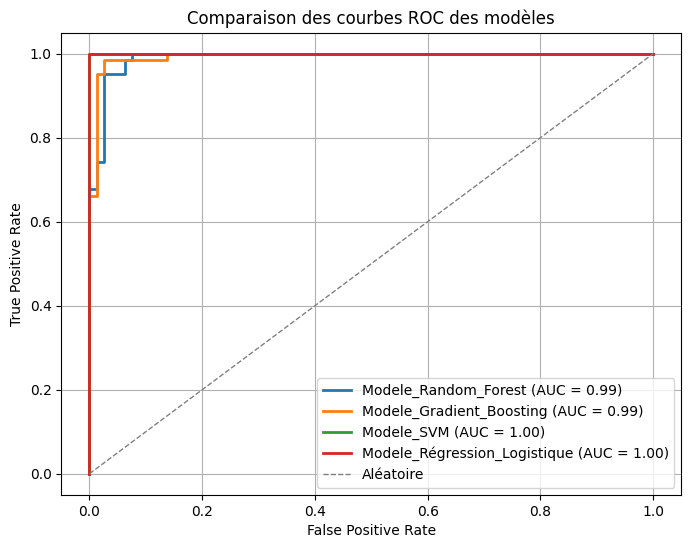

In [128]:
plt.figure(figsize=(8,6))

for modele_key, pipeline in models_best_estimators.items():

    # Probabilités prédictives de la classe positive (classe 1)
    try:
        y_proba = pipeline.predict_proba(X_test)[:, 1]
    except AttributeError:
        # Si predict_proba indisponible, on saute ce modèle
        print(f"{modele_key} : predict_proba() non disponible, courbe ROC non tracée.")
        continue
    
    fpr, tpr, _ = roc_curve(y_test, y_proba, pos_label=1)
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, lw=2, label=f'{modele_key} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], color='grey', lw=1, linestyle='--', label='Aléatoire')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Comparaison des courbes ROC des modèles')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


La courbe nous confirme que les deux derniers models obtiennent des resultats parfaits.

###   🚀 `Interpretation des résultas`

* Le modele choisi est la regression logistique.

* L'ajustement des paramétres nous a permis de calculer le F1 pour la cross-validation (0.99) et pour le jeu test (1.0) il s'agit des meilleures résultats pour les quatres modèles testés. Il n'y a pas une grande différence entre les deux donc nous ne somme pas dans un cas d'overfitting.

* La matrice de confusion nous montre que toutes les données du jeu test  ont été correctement classées.

**Ensuite nous avons les résultats pour:**

* l'accuracy qui calcule vp / (vp + fp)

* le recall qui calcule vp / (vp +fn)

* le F1 qui combine les deux précedentes metriques

* Pour notre modèle toutes les metriques sont à 1 ce qui est le maximum.

                    Feature  Importance
0                   Glucose    7.594701
4                       Age    7.391755
1             BloodPressure    6.661950
2                       BMI    4.997108
3  DiabetesPedigreeFunction    1.396718


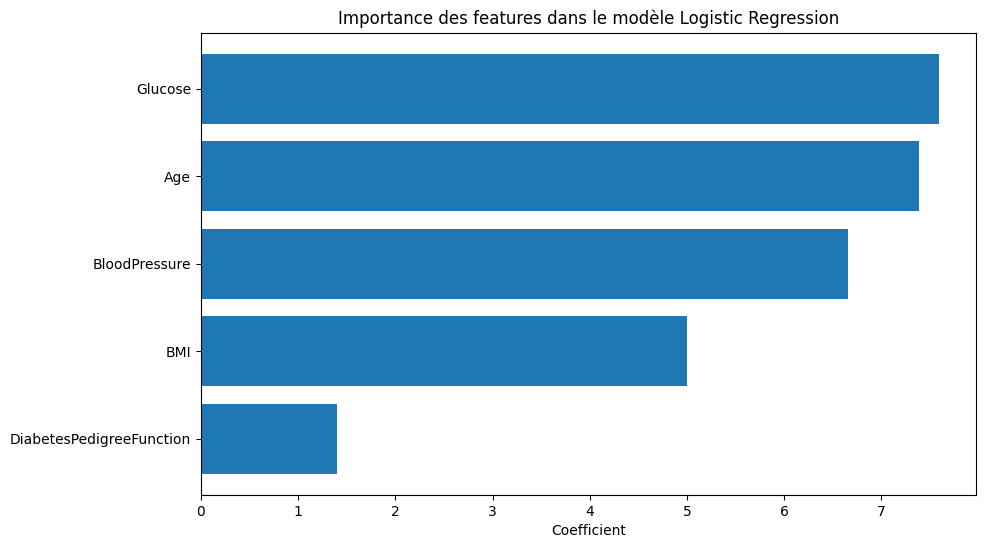

In [129]:
logistic_pipeline = models_best_estimators['Modele_Régression_Logistique']
logistic_model = logistic_pipeline.named_steps['clf']  # le classificateur LogisticRegression

# Récupérer les coefficients (importance des features), pour la classe 1 (première classe)
coefficients = logistic_model.coef_[0]

# Récupérer le nom des variables utilisées
feature_names = X_train.columns

# Créer un DataFrame pour mieux visualiser
feat_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': coefficients
})

# Trier par importance absolue décroissante
feat_importance['Abs_Importance'] = feat_importance['Importance'].abs()
feat_importance = feat_importance.sort_values(by='Abs_Importance', ascending=False)

print(feat_importance[['Feature', 'Importance']])

# Visualiser avec un graphique à barres
plt.figure(figsize=(10,6))
plt.barh(feat_importance['Feature'], feat_importance['Importance'])
plt.xlabel('Coefficient')
plt.title('Importance des features dans le modèle Logistic Regression')
plt.gca().invert_yaxis()  # pour avoir la feature la plus importante en haut
plt.show()


Dans notre modèle le glucose, l'age et BloodPressure sont les facteurs les plus important.

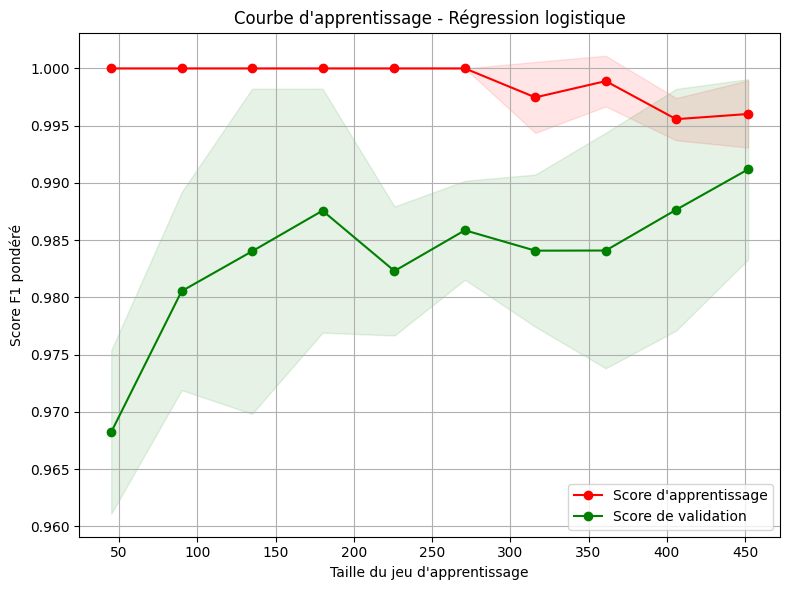

In [130]:
train_sizes, train_scores, test_scores = learning_curve(
    estimator=logistic_pipeline,
    X= X_train,
    y= y_train,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10),
    random_state=42
)

train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)

plt.figure(figsize=(8,6))
plt.plot(train_sizes, train_scores_mean, 'o-', color='r', label="Score d'apprentissage")
plt.plot(train_sizes, test_scores_mean, 'o-', color='g', label="Score de validation")
plt.fill_between(train_sizes, train_scores_mean-train_scores_std, train_scores_mean+train_scores_std, alpha=0.1, color='r')
plt.fill_between(train_sizes, test_scores_mean-test_scores_std, test_scores_mean+test_scores_std, alpha=0.1, color='g')
plt.xlabel("Taille du jeu d'apprentissage")
plt.ylabel("Score F1 pondéré")
plt.title("Courbe d'apprentissage - Régression logistique")
plt.legend(loc='best')
plt.grid()
plt.tight_layout()
plt.show()

Le score de validation rejoint celui d'apprentissage ce qui montre qu'on est pas dans un cas d'overfitting.

Sauvegarde du model

In [131]:
model = models_best_estimators.get("Modele_Régression_Logistique")
joblib.dump(model, '..\\models\\model.pkl')

['..\\models\\model.pkl']